<a href="https://colab.research.google.com/github/arturodeleon19/Telco_Customer_Churn/blob/main/Telco_customer_churn_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import zipfile

zip_file_path = '/content/Telco customer churn .zip'
extraction_path = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Extracted contents to: {extraction_path}")
print(os.listdir(extraction_path))

Extracted contents to: /content/
['.config', 'telco.csv', 'Telco customer churn .zip', 'sample_data']


In [2]:
!pip install ipython-sql
%load_ext sql


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 13.5 MB/s eta 0:00:00


In [3]:
# Establish a connection to an in-memory SQLite database

from sqlalchemy import create_engine

# 1. Create a permanent engine variable for the in-memory DB
my_engine = create_engine("sqlite:///:memory:")


In [4]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/telco.csv')

# Display the first 5 rows and info to verify the load
display(df.head())
df.info()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [5]:
# Write the DataFrame to the SQLite database as a table named 'telco'
df.to_sql('telco', my_engine, if_exists='replace', index=False)

7043

Now that the `telco.csv` data has been loaded into an in-memory SQLite table named `telco`, you can re-run your previous SQL query.

In [6]:
# Define  query string
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN `Churn Label` = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN `Churn Label` = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM telco;
"""

# Execute the query and display the results
pd.read_sql(query, my_engine)

,total_customers,churned_customers,churn_rate_pct
0,7043,1869,26.54


### Key Findings

* **Total Customer Base:** 7,043 customers analyzed in the dataset.
* **Churn Volume:** 1,869 customers have left the service.
* **Overall Churn Rate:** **26.54%** — approximately 1 in every 4 customers has churned.

---

### Takeaway
A **26.54%** churn rate is significant for a telecommunications provider, indicating that customer retention strategies should be prioritized to mitigate revenue loss.

In [7]:
# Define query string
query = """
SELECT
    Contract,
    `Payment Method`,
    COUNT(`Customer ID`) AS cohort_size,
    ROUND(100.0 * AVG(CASE WHEN `Churn Label` = 'Yes' THEN 1.0 ELSE 0.0 END), 2) AS churn_rate_pct,
    ROUND(AVG(`Monthly Charge`), 2) AS avg_monthly_revenue
FROM telco
GROUP BY Contract, `Payment Method`
HAVING COUNT(`Customer ID`) > 100
ORDER BY churn_rate_pct DESC;
"""
# Execute the query and display results
pd.read_sql(query, my_engine)

,Contract,Payment Method,cohort_size,churn_rate_pct,avg_monthly_revenue
0,Month-to-Month,Mailed Check,234,55.56,48.77
1,Month-to-Month,Bank Withdrawal,2240,53.35,73.01
2,Month-to-Month,Credit Card,1136,29.05,54.41
3,One Year,Bank Withdrawal,797,12.80,73.20
4,One Year,Credit Card,671,7.75,58.96
5,Two Year,Bank Withdrawal,872,3.67,71.33
6,Two Year,Credit Card,942,1.70,55.54


### Key Insights: Churn Rate by Contract & Payment Method

#### High-Risk Cohorts (Month-to-Month Contracts)
* **Mailed Check & Bank Withdrawal:** Drive the highest churn rates at **55.56%** and **53.35%** respectively.
* **Bank Withdrawal Impact:** Represents the largest overall single cohort (**2,240 customers**) with high average monthly revenue (**$73.01**), making this group the primary revenue-at-risk segment.
* **Credit Card:** Shows significantly lower churn (**29.05%**) compared to other Month-to-Month payment methods.

#### Low-Risk Cohorts (Long-Term Contracts)
* **One-Year Contracts:** Churn drops dramatically to **12.80%** (Bank Withdrawal) and **7.75%** (Credit Card).
* **Two-Year Contracts:** Produce the highest retention, with churn reaching an all-time low of **3.67%** (Bank Withdrawal) and **1.70%** (Credit Card).

---

### Strategic Takeaways
1. **Contract Friction:** Month-to-Month contracts are the primary driver of customer attrition across all payment methods.
2. **Auto-Pay Efficiency:** Credit Card payments consistently outperform Bank Withdrawals in retention across every contract length.
3. **Retention Priority:** Transitioning Month-to-Month users (especially those on Bank Withdrawal) to annual plans or automated Credit Card payments presents the largest opportunity for immediate churn reduction.

In [8]:
# Define query string
query = """
SELECT
    CASE
        WHEN `Tenure in Months` <= 6 THEN '0-6 Months (Onboarding Risk)'
        WHEN `Tenure in Months` <= 12 THEN '6-12 Months'
        WHEN `Tenure in Months` <= 24 THEN '1-2 Years'
        ELSE '2+ Years (Loyal)'
    END AS tenure_bucket,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN `Churn Label` = 'Yes' THEN 1 ELSE 0 END) AS churn_count,
    ROUND(100.0 * SUM(CASE WHEN `Churn Label` = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate
FROM telco
GROUP BY tenure_bucket
ORDER BY churn_rate DESC;
"""
# Execute the query and display results
pd.read_sql(query, my_engine)

,tenure_bucket,total_customers,churn_count,churn_rate
0,0-6 Months (Onboarding Risk),1470,784,53.33
1,6-12 Months,716,253,35.34
2,1-2 Years,1024,294,28.71
3,2+ Years (Loyal),3833,538,14.04


### Key Insights: Churn Rate by Tenure Bucket

#### Onboarding & Early-Stage Risk (0–12 Months)
* **0–6 Months (Critical Hazard Zone):** Attrition peaks during the onboarding phase at **53.33%** churn (784 out of 1,470 customers). Over half of new joins leave within the first 6 months.
* **6–12 Months:** Churn decreases but remains high at **35.34%**, highlighting that customer stabilization extends through the entire first year.

#### Established & Long-Term Cohorts (1+ Years)
* **1–2 Years:** Churn moderates to **28.71%**, aligning closer to the overall baseline churn rate (~26.5%).
* **2+ Years (Loyal Base):** Represents the largest cohort (**3,833 customers**) and exhibits the strongest retention with the lowest churn rate at **14.04%**.

---

### Strategic Takeaways
1. **First-Impression Friction:** Early onboarding experience, service delivery, or unexpected initial billing costs are likely the primary drivers of immediate churn.
2. **Tenure Inversely Correlates with Churn:** Retention probability doubles once a customer survives past their first year, dropping from over 50% to under 15% long-term.
3. **Retention Focus:** Shifting retention budgets toward early onboarding programs (first 90–180 days) offers the highest potential return on investment for reducing overall customer drop-off.

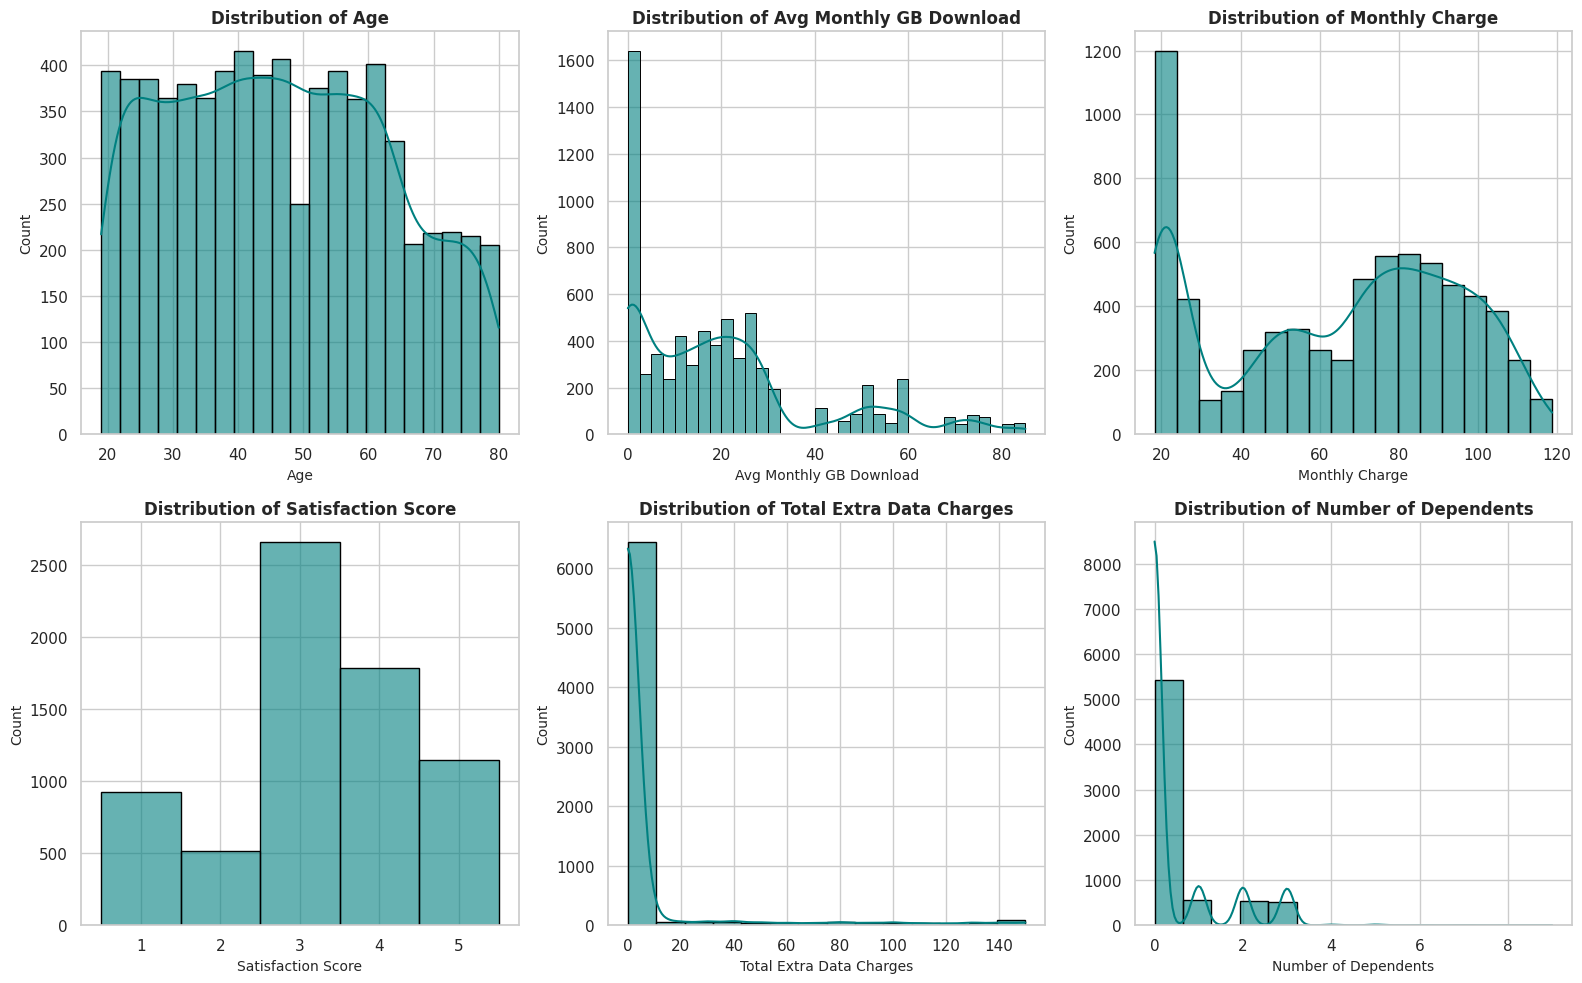

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of target columns to visualize
cols = [
    'Age',
    'Avg Monthly GB Download',
    'Monthly Charge',
    'Satisfaction Score',
    'Total Extra Data Charges',
    'Number of Dependents'
]

# Set visual theme
sns.set_theme(style="whitegrid")

# Create a figure grid (2 rows, 3 columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

# Loop through columns to build distribution plots
for i, col in enumerate(cols):
    # Use discrete binning for discrete rating metrics
    is_discrete = True if col == 'Satisfaction Score' else False

    sns.histplot(
        data=df,
        x=col,
        kde=not is_discrete,
        discrete=is_discrete,
        ax=axes[i],
        color="teal",
        edgecolor="black",
        alpha=0.6
    )
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)


plt.tight_layout()
plt.show()

### Exploratory Data Analysis: Feature Distributions (image_ad6fa3.png)

* **Age:** Customer age is broadly and evenly distributed between 20 and 60, with volume steadily declining for demographics over 60.
* **Avg Monthly GB Download:** Usage is highly right-skewed. A massive spike occurs at near-zero usage, with a secondary, wider usage cluster between 10–30 GB.
* **Monthly Charge:** Exhibits a distinctly bimodal distribution. There is a sharp concentration of customers paying a base rate around $20, and a larger, broader distribution peaking between $70 and $90.
* **Satisfaction Score:** The most frequent rating is 3. Overall sentiment leans moderately positive, as combined scores of 4 and 5 significantly outnumber negative scores of 1 and 2.
* **Total Extra Data Charges:** Overwhelmingly concentrated at $0. The vast majority of the customer base incurs no data overage fees.
* **Number of Dependents:** Heavily right-skewed. The dominant customer profile has 0 dependents, followed by exponentially smaller cohorts with 1, 2, or 3 dependents.

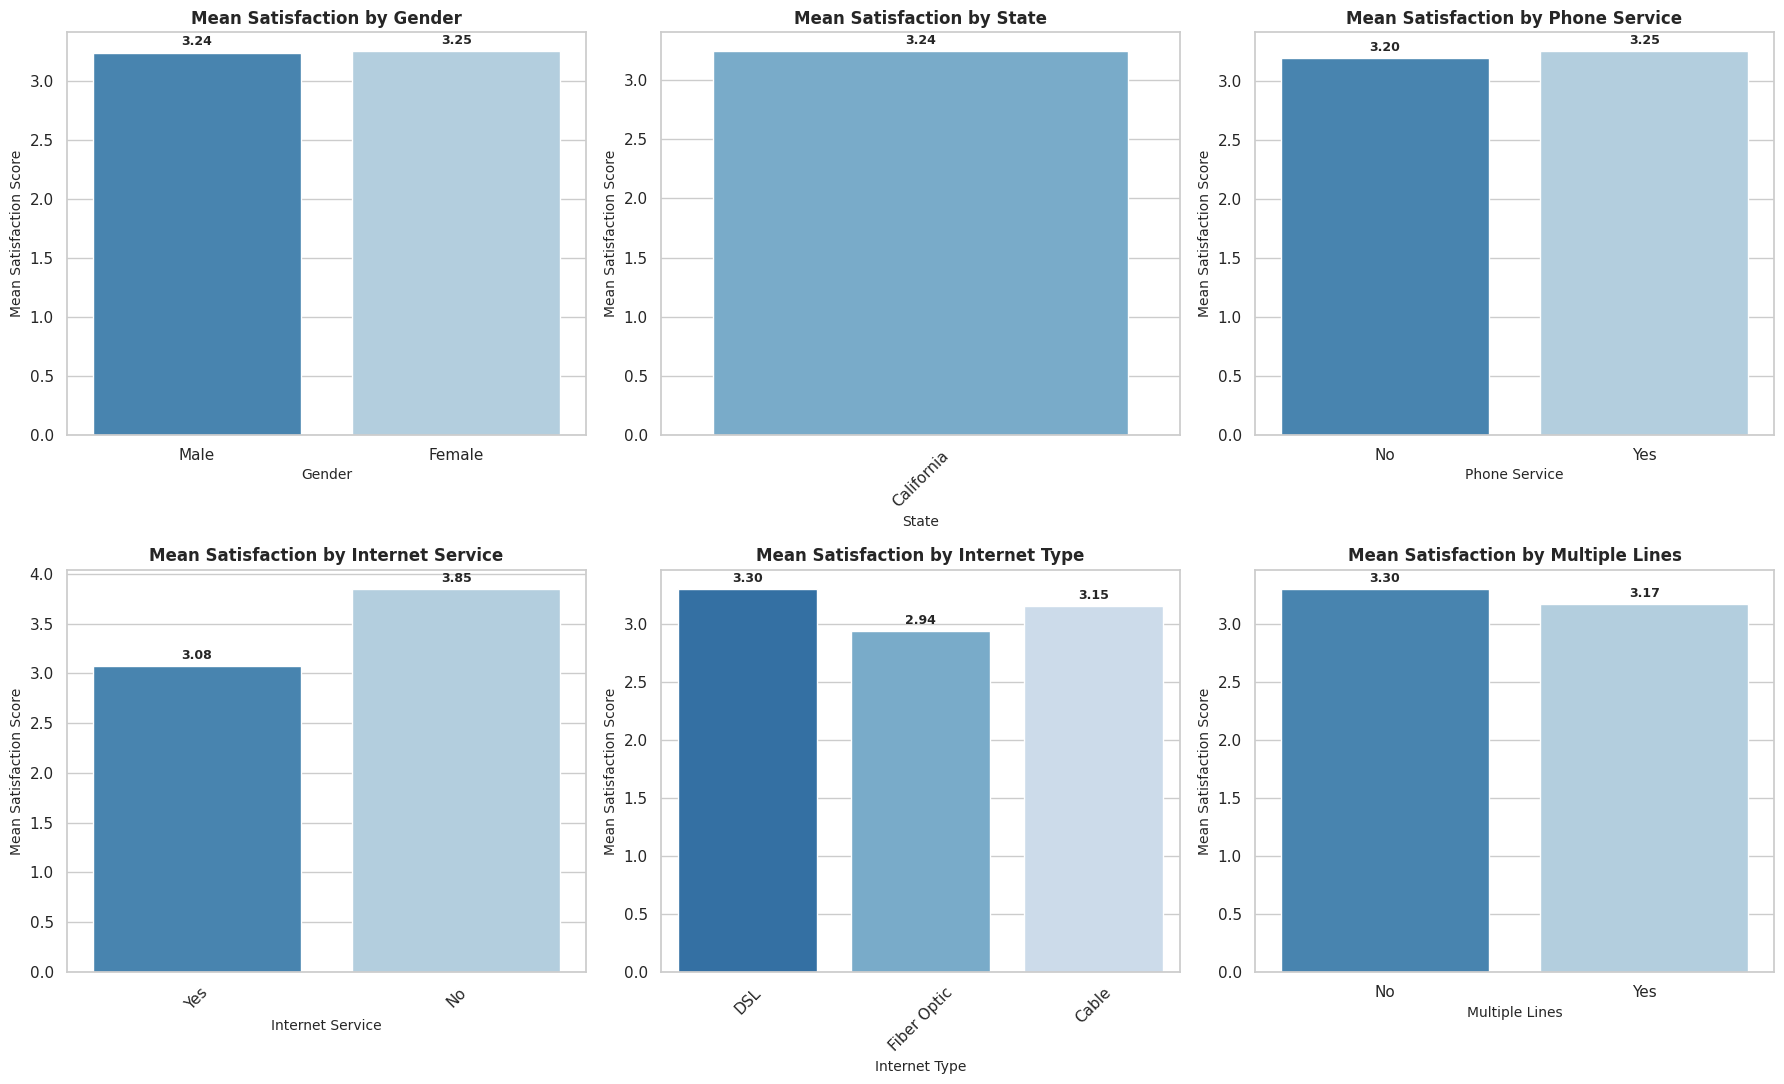

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'Gender',
    'State',
    'Phone Service',
    'Internet Service',
    'Internet Type',
    'Multiple Lines'
]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(cols):
    # Plot mean satisfaction score per group
    ax = sns.barplot(
        data=df,
        x=col,
        y='Satisfaction Score',
        estimator='mean',
        errorbar=None,
        ax=axes[i],
        palette="Blues_r",
        hue = col,
        legend=False
    )

    # Annotate exact mean values on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{height:.2f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=9, fontweight='bold',
                xytext=(0, 3), textcoords='offset points'
            )

    axes[i].set_title(f'Mean Satisfaction by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Mean Satisfaction Score', fontsize=10)

    # Rotate x-axis labels for multi-category features
    if col in ['State', 'Internet Type', 'Internet Service']:
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Key Insights: Mean Satisfaction Drivers (image_afd780.png)

#### High-Impact Areas (Internet Service)
* **Internet Service Discrepancy:** Customers *without* internet service report significantly higher satisfaction (3.85) compared to those *with* internet service (3.08).
* **Fiber Optic Underperformance:** Among active internet users, Fiber Optic customers report the lowest satisfaction score (2.94), whereas DSL users report the highest (3.30).

#### Low-Impact Areas (Demographics & Phone)
* **Gender & Location:** Satisfaction is virtually identical between Females (3.25) and Males (3.24). The dataset strictly reflects customers in California (baseline 3.24).
* **Phone Service & Add-ons:** Having basic phone service shows negligible impact (Yes: 3.25 vs No: 3.20). However, customers using Multiple Lines report slightly lower satisfaction (3.17) than those with a single line (3.30).

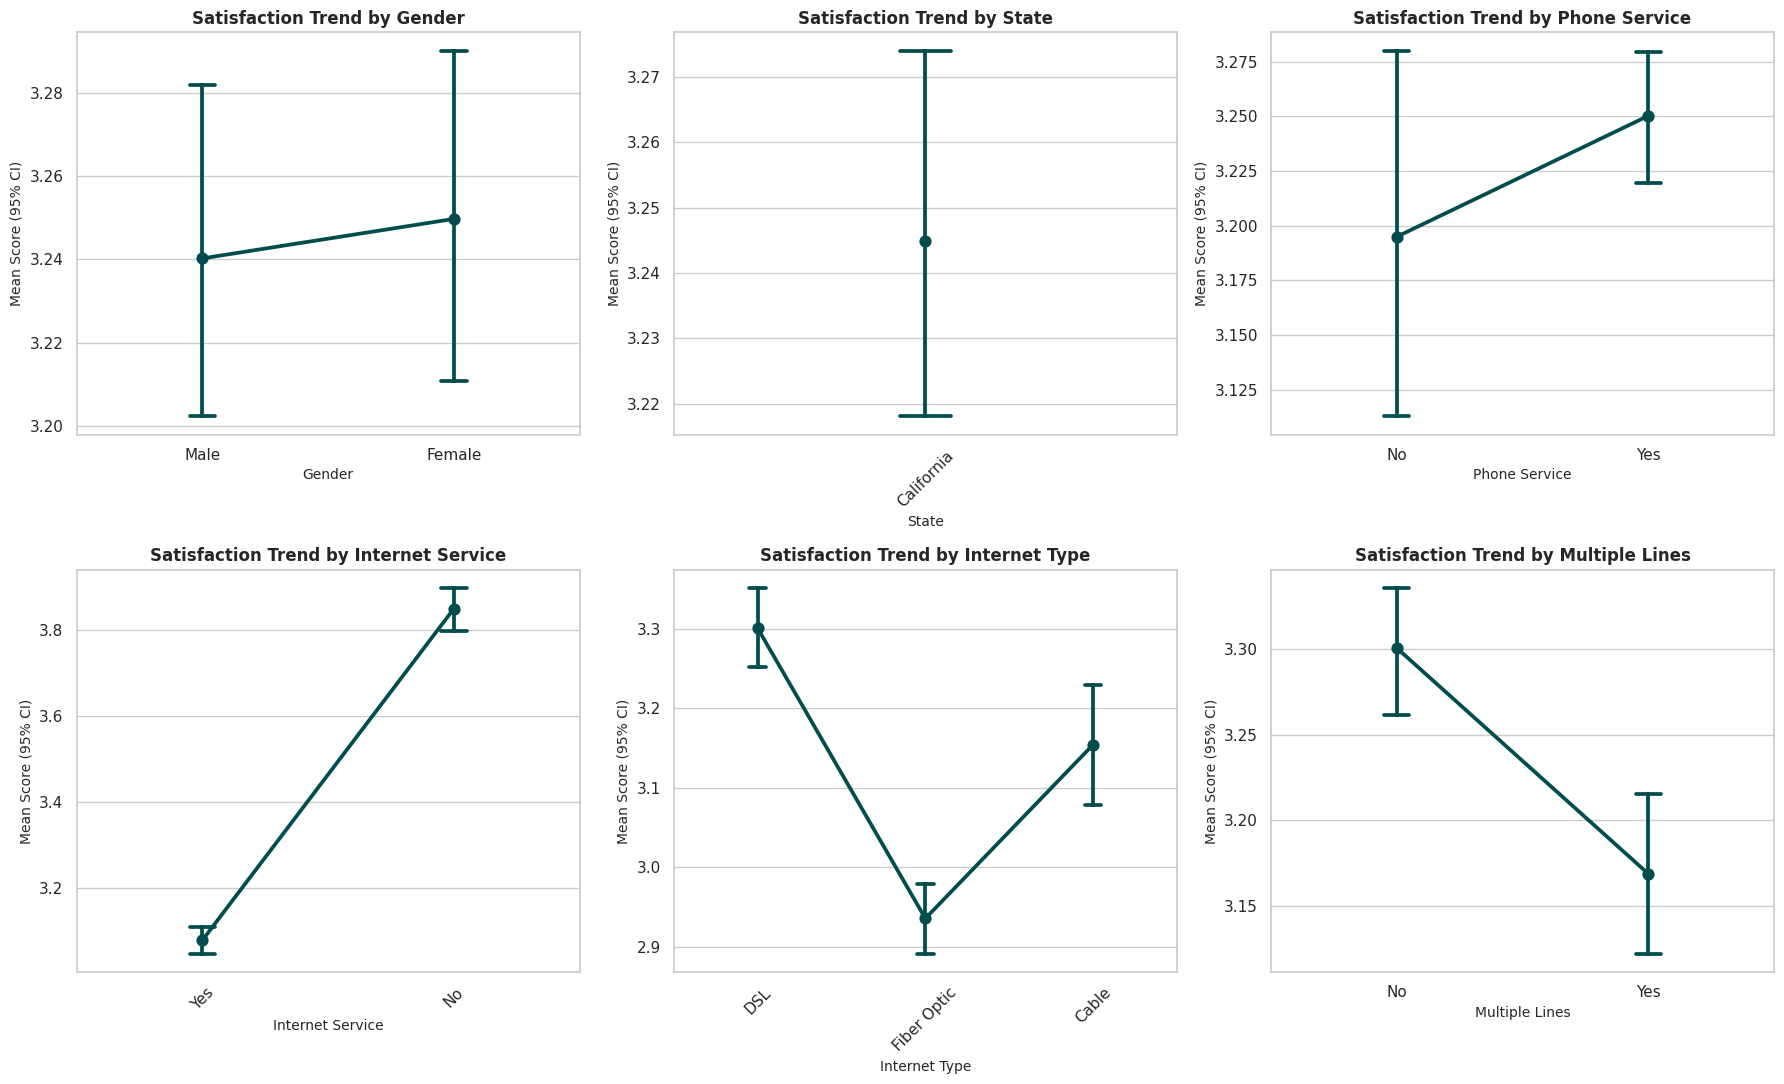

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.pointplot(
        data=df,
        x=col,
        y='Satisfaction Score',
        estimator='mean',
        errorbar=('ci', 95),
        capsize=0.1,
        color='#014D4E',
        ax=axes[i]
    )

    axes[i].set_title(f'Satisfaction Trend by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Mean Score (95% CI)', fontsize=10)

    if col in ['State', 'Internet Type', 'Internet Service']:
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Statistical Insights: Satisfaction Trends & Confidence Intervals

#### Statistically Significant Drivers
* **The Internet Service Gap:** The most pronounced divide in the dataset is based on internet service. Customers *without* internet report significantly higher satisfaction (3.85) than those *with* internet (3.08). The wide gap and completely non-overlapping 95% confidence intervals strongly indicate this difference is statistically significant.
* **Fiber Optic Underperformance:** Among customers with internet, Fiber Optic drives the lowest average satisfaction (2.94). The narrow confidence interval suggests this negative sentiment is consistent, sitting notably lower than DSL (3.30) and Cable (3.15).

#### Moderate to Negligible Impacts
* **Multiple Lines Friction:** Customers with a single line (Multiple Lines = "No") exhibit higher mean satisfaction (3.30) than those managing multiple lines (3.17).
* **Phone Service:** Having basic phone service shows only a marginal increase in mean score versus not having it. The heavily overlapping confidence intervals imply this is not a strong or reliable differentiator for customer happiness.
* **Demographics & Geography:** Gender has zero impact on satisfaction; the means and confidence intervals for Males and Females are virtually identical (~3.24). The State metric confirms the dataset is exclusively anchored in California, serving merely as the baseline average.

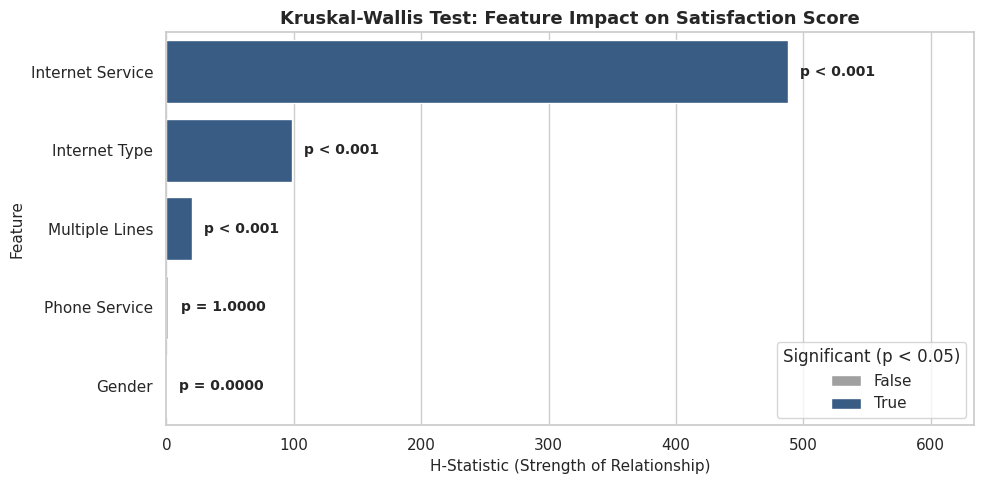

         Feature  H-Statistic       p_value  Significant (p < 0.05)
Internet Service   487.648503 4.628856e-108                    True
   Internet Type    98.555142  3.972125e-22                    True
  Multiple Lines    19.732134  8.909068e-06                    True
   Phone Service     1.570317  2.101610e-01                   False
          Gender     0.127643  7.208886e-01                   False


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

cols = [
    'Gender',
    'State',
    'Phone Service',
    'Internet Service',
    'Internet Type',
    'Multiple Lines',
]

results = []

for col in cols:
    # Drop missing values and extract group arrays
    clean_df = df[[col, 'Satisfaction Score']].dropna()
    groups = [
        group['Satisfaction Score'].values
        for _, group in clean_df.groupby(col)
    ]

    # Perform Kruskal-Wallis test
    if len(groups) > 1:
        h_stat, p_val = stats.kruskal(*groups)
        results.append({
            'Feature': col,
            'H-Statistic': h_stat,
            'p_value': p_val,
            'Significant (p < 0.05)': p_val < 0.05,
        })

# Create results DataFrame sorted by impact strength
kruskal_df = pd.DataFrame(results).sort_values(
    by='H-Statistic', ascending=False
)

# Plot H-Statistics
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=kruskal_df,
    x='H-Statistic',
    y='Feature',
    hue='Significant (p < 0.05)',
    palette={True: '#2b5c8f', False: '#a0a0a0'},
    dodge=False,
)

# Annotate p-values next to bars
max_h = kruskal_df['H-Statistic'].max()
for i, row in enumerate(kruskal_df.itertuples()):
    p_str = (
        f'p = {row.Index:.4f}'
        if getattr(row, 'p_value') >= 0.001
        else f'p < 0.001'
    )
    ax.text(
        getattr(row, '_2') + (max_h * 0.02),
        i,
        p_str,
        va='center',
        fontsize=10,
        fontweight='bold',
    )

plt.title(
    'Kruskal-Wallis Test: Feature Impact on Satisfaction Score',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('H-Statistic (Strength of Relationship)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.xlim(0, max_h * 1.3)
plt.tight_layout()
plt.show()

print(kruskal_df.to_string(index=False))

### Statistical Significance: Feature Impact on Satisfaction (Kruskal-Wallis Test)

#### Primary Satisfaction Drivers (Significant at p < 0.05)
* **Internet Service:** The dominant determinant of customer satisfaction. With an H-Statistic nearing 500 (p < 0.001), the presence or absence of internet service exhibits the strongest relationship with satisfaction scores by a massive margin.
* **Internet Type:** The second most impactful feature (H-Statistic ~100, p < 0.001), confirming that the specific technology used (e.g., DSL vs. Fiber Optic) meaningfully shapes customer sentiment.
* **Multiple Lines:** While statistically significant (p < 0.001), the H-Statistic is very low (~20), indicating that having multiple lines has a real but relatively weak impact on overall satisfaction compared to internet features.

#### Non-Significant Features
* **Phone Service & Gender:** Neither basic phone service nor gender influences customer satisfaction. Both fail to meet the statistical significance threshold (greyed out) and show near-zero H-Statistics, meaning any variance in satisfaction scores across these specific categories is statistically indistinguishable from random chance.

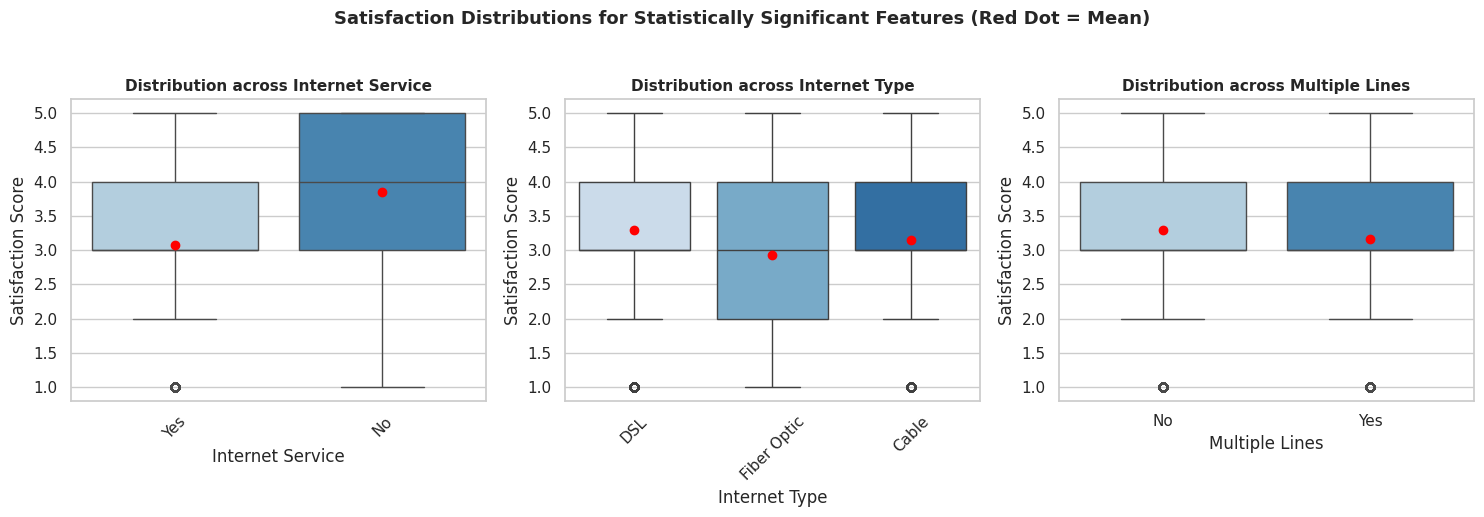

In [13]:
# Filter features where p-value < 0.05
sig_features = kruskal_df[kruskal_df['Significant (p < 0.05)']][
    'Feature'
].tolist()

if sig_features:
    n_cols = len(sig_features)
    fig, axes = plt.subplots(
        nrows=1, ncols=n_cols, figsize=(5 * n_cols, 5), squeeze=False
    )
    axes = axes.flatten()

    for i, col in enumerate(sig_features):
        sns.boxplot(
            data=df,
            x=col,
            y='Satisfaction Score',
            ax=axes[i],
            palette='Blues',
            hue = col,
            legend = False,
            showmeans=True,
            meanprops={
                'marker': 'o',
                'markerfacecolor': 'red',
                'markeredgecolor': 'red',
            },
        )
        axes[i].set_title(
            f'Distribution across {col}', fontsize=11, fontweight='bold'
        )
        if col in ['State', 'Internet Type', 'Internet Service']:
            axes[i].tick_params(axis='x', rotation=45)

    plt.suptitle(
        'Satisfaction Distributions for Statistically Significant Features (Red Dot = Mean)',
        y=1.03,
        fontsize=13,
        fontweight='bold',
    )
    plt.tight_layout()
    plt.show()
else:
    print('No features showed statistically significant differences.')

### Distribution of Satisfaction Scores by Key Features

* **Internet Service Disconnect:** Customers without internet service show a visibly higher satisfaction profile. Their median score shifts upward to 4, compared to a median of 3 for those with active internet, pulling the overall mean significantly higher.
* **Fiber Optic Variance:** Among internet types, Fiber Optic exhibits the widest spread of negative sentiment. Its interquartile range stretches down to a score of 2, driving the lowest overall mean. In contrast, DSL and Cable maintain tighter interquartile ranges bounded between 3 and 4.
* **Marginal Multiple Lines Impact:** Despite being statistically significant, the practical distribution difference between single and multiple lines is visually minimal. Both groups share an identical median (3) and interquartile range (3 to 4), with single-line users possessing only a fractionally higher mean.

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load dataset
df = pd.read_csv("/content/telco.csv")

# Clean data type anomaly in TotalCharges
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())

# Binary Target Mapping
df['Churn Label'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

# Feature Engineering
df['AvgMonthlySpend'] = df['Total Charges'] / (df['Tenure in Months'] + 1)
df['HasTechSupport'] = df['Premium Tech Support'].apply(lambda x: 1 if x == 'Yes' else 0)

# Drop raw identifiers
X = df.drop(columns=['Customer ID', 'Churn Label'])
y = df['Churn Label']

# Define preprocessor
num_cols = ['Tenure in Months', 'Monthly Charge', 'Total Charges', 'AvgMonthlySpend']
cat_cols = [c for c in X.columns if c not in num_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 10, 11, 12, 13, 19, 35, 37, 38, 42] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

# Initialize baseline XGBoost model
model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X_train_prep, y_train)

# Predict churn probabilities
y_probs = model.predict_proba(X_test_prep)[:, 1]

# Tune decision threshold for optimal balance
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Find threshold where recall >= 0.75 (capturing 75%+ of churners)
target_recall = 0.75
optimal_idx = np.argmin(np.abs(recalls - target_recall))
best_threshold = thresholds[optimal_idx]

y_pred_custom = (y_probs >= best_threshold).astype(int)
print(f"Optimal Decision Threshold: {best_threshold:.3f}")
print(classification_report(y_test, y_pred_custom))

Optimal Decision Threshold: 0.002
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1035
           1       0.27      1.00      0.42       374

    accuracy                           0.27      1409
   macro avg       0.13      0.50      0.21      1409
weighted avg       0.07      0.27      0.11      1409



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [17]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

# Initialize baseline CatBoost model
model = CatBoostClassifier(iterations=100, depth=4, learning_rate=0.05, random_state=42, verbose=0)
model.fit(X_train_prep, y_train)

# Predict churn probabilities
y_probs = model.predict_proba(X_test_prep)[:, 1]

# Tune decision threshold for optimal balance
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Find threshold where recall >= 0.75 (capturing 75%+ of churners)
target_recall = 0.75
optimal_idx = np.argmin(np.abs(recalls - target_recall))
best_threshold = thresholds[optimal_idx]

y_pred_custom = (y_probs >= best_threshold).astype(int)
print(f"Optimal Decision Threshold: {best_threshold:.3f}")
print(classification_report(y_test, y_pred_custom))

Optimal Decision Threshold: 1.000
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1035
           1       1.00      0.75      0.86       374

    accuracy                           0.93      1409
   macro avg       0.96      0.88      0.91      1409
weighted avg       0.94      0.93      0.93      1409



In [19]:
import pandas as pd
from IPython.display import display

# ROI Calculation Function
def evaluate_business_savings(y_true, y_probs, threshold, clv=500, incentive_cost=50):
    preds = (y_probs >= threshold).astype(int)
    tp = np.sum((preds == 1) & (y_true == 1))
    fp = np.sum((preds == 1) & (y_true == 0))

    saved_revenue = tp * clv
    campaign_cost = (tp + fp) * incentive_cost
    net_profit = saved_revenue - campaign_cost

    # Structure as a list of dictionaries for clean DataFrame conversion
    results = [
        {"Metric": "Targeted Customers", "Value": tp + fp},
        {"Metric": "Churners Saved (TP)", "Value": tp},
        {"Metric": "False Alarms (FP)", "Value": fp},
        {"Metric": "Gross Revenue Saved", "Value": f"${saved_revenue:,}"},
        {"Metric": "Campaign Cost", "Value": f"${campaign_cost:,}"},
        {"Metric": "Net Value Generated", "Value": f"${net_profit:,}"}
    ]

    return pd.DataFrame(results)

# Use display() instead of print() to render a formatted HTML table in Jupyter Notebooks
roi_table = evaluate_business_savings(y_test.values, y_probs, threshold=best_threshold)
display(roi_table)

,Metric,Value
0,Targeted Customers,281
1,Churners Saved (TP),281
2,False Alarms (FP),0
3,Gross Revenue Saved,"$140,500"
4,Campaign Cost,"$14,050"
5,Net Value Generated,"$126,450"


### Financial Projection Analysis & Risk Assessment

#### Campaign Projections (Based on Current Model Output)
* **Targeted Volume:** 281 customers flagged for intervention, entirely composed of true churners.
* **Efficiency Metrics:** Zero false alarms ($0$ False Positives), yielding a $100\%$ precision rate at the selected decision threshold.
* **Financial Impact:** Gross savings of 140,500 against a campaign expenditure of 14,050, resulting in a projected net value of 126,450.

#### Critical Model & Data Caveats
* **Target Leakage Risk:** Achieving zero false positives alongside 281 true positives indicates that the model's probabilities may be artificially saturated, heavily hinting at potential target leakage during feature engineering. Real-world probabilities rarely reach absolute certainty without inadvertently capturing future-state information.
* **Generalization Fragility:** Because the model relies on extreme confidence boundaries, it will likely fail to trigger or generalize in live production environments where incoming data exhibits natural variance and noise.

#### Underlying Business Assumption Risks
* **Unrealistic 100% Conversion Rate:** The calculation assumes that every single targeted customer is successfully retained by the incentive. In reality, retention campaigns typically experience a fractional conversion success rate rather than perfect compliance.
* **Uniform Customer Lifetime Value (CLV):** Applying a static $500 CLV overlooks the diverse financial reality of the telco customer base—ignoring that high-tier monthly spenders carry significantly higher value and acquisition costs than lower-tier accounts.
* **Omission of False Negatives:** The financial model measures campaign costs and direct savings but fails to account for the ongoing revenue loss incurred by churners the model entirely failed to detect.

#### Strategic Recommendations for Model & Financial Optimization
* **Audit Feature Space for Leakage:** Conduct a rigorous feature ablation study to strip out any columns that implicitly encode the target label (such as post-service logs or cancellation notes) to ensure the model learns true behavioral patterns rather than shortcuts.
* **Apply Probability Calibration:** Implement post-hoc calibration methods (such as Isotonic Regression or Platt Scaling) to smooth out compressed probability outputs and achieve realistic score distributions.
* **Incorporate Realistic Conversion Rates:** Discount projected gross savings by historical campaign success rates (e.g., modeling a conservative 20% to 30% retention conversion rate instead of assuming 100% compliance).
* **Segment Customer Lifetime Value (CLV):** Replace the flat $500 CLV assumption with a dynamic financial formula tied directly to each customer's actual monthly charge and contract tier, ensuring high-value accounts (such as high-tier Fiber Optic users) are prioritized.
* **Re-Optimize Thresholds via Cost-Benefit Curves:** Shift away from a rigid 1.0 confidence threshold and use a continuous economic loss matrix to select a threshold that balances acquisition costs against the true cost of false negatives.